# Titanic Survival Prediction

## End-to-End Machine Learning Classification Project

---

## Project Overview

The objective of this project is to build a Machine Learning model that predicts whether a passenger survived the Titanic disaster based on passenger information such as age, gender, passenger class, fare, and embarkation details.

This project demonstrates the complete Machine Learning workflow, from data exploration and preprocessing to model training, evaluation, and hyperparameter tuning using a Decision Tree Classifier.

---

## Dataset Information

- **Dataset:** Titanic Dataset (Kaggle)
- **Problem Type:** Binary Classification
- **Target Variable:** `Survived`
- **Target Classes:**
  - `0` → Not Survived
  - `1` → Survived

---

# Project Workflow

## 1. Import Libraries

Import all the required Python libraries.

---

## 2. Load Dataset

Load the Titanic dataset into a Pandas DataFrame.

---

## 3. Dataset Overview

Understand the dataset by examining:
- Shape
- Columns
- Data Types
- Missing Values
- Summary Statistics

---

## 4. Exploratory Data Analysis (EDA)

Analyze the dataset to identify:
- Missing Values
- Duplicate Records
- Feature Distributions
- Target Distribution
- Correlation
- Outliers

---

## 5. Data Cleaning

Prepare the dataset by:
- Handling Missing Values
- Removing Duplicates
- Encoding Categorical Features
- Feature Engineering

---

## 6. Feature Selection

Select the input features (**X**) and target variable (**y**).

---

## 7. Train-Test Split

Split the dataset into training and testing sets.

---

## 8. Data Preprocessing

Prepare the data for model training using preprocessing techniques.

---

## 9. Model Building

Train a Decision Tree Classifier.

---

## 10. Model Evaluation

Evaluate the model using:
- Accuracy Score
- Confusion Matrix
- Classification Report

---

## 11. Hyperparameter Tuning

Optimize the Decision Tree using GridSearchCV.

---

## 12. Feature Importance

Identify the most influential features used by the model.

---

## 13. Decision Tree Visualization

Visualize the trained Decision Tree to understand the decision-making process.

---

## 14. Conclusion

Summarize the project, observations, model performance, and key learnings.

In [ ]:
import numbers as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv(r"C:\TITANIC-SURVIVAL-PREDICTION\datasets\Titanic-Dataset.csv")
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [3]:
df.shape

(891, 12)

In [4]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [5]:
df.drop('PassengerId', axis=1, inplace=True)
df.columns

Index(['Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket',
       'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [6]:
df.shape

(891, 11)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Name      891 non-null    object 
 3   Sex       891 non-null    object 
 4   Age       714 non-null    float64
 5   SibSp     891 non-null    int64  
 6   Parch     891 non-null    int64  
 7   Ticket    891 non-null    object 
 8   Fare      891 non-null    float64
 9   Cabin     204 non-null    object 
 10  Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 76.7+ KB


In [8]:
df.describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [9]:
df.isnull().sum()

Survived      0
Pclass        0
Name          0
Sex           0
Age         177
SibSp         0
Parch         0
Ticket        0
Fare          0
Cabin       687
Embarked      2
dtype: int64

In [10]:
df.drop('Cabin', axis=1, inplace=True)
df.columns

Index(['Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket',
       'Fare', 'Embarked'],
      dtype='object')

<Axes: ylabel='Frequency'>

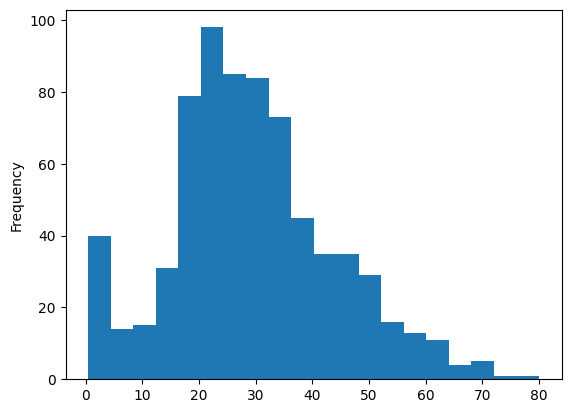

In [11]:
df['Age'].plot(kind='hist', bins=20)

<Axes: xlabel='Age', ylabel='Count'>

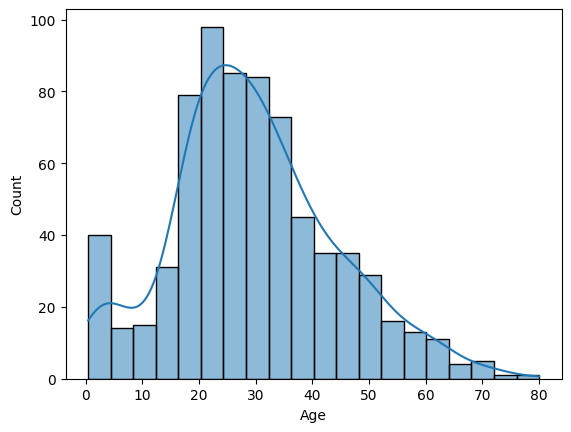

In [12]:
import seaborn as sns
sns.histplot(df['Age'], bins=20, kde=True)

In [13]:
x = df.drop('Survived', axis=1)
y = df['Survived']

In [14]:
print(x.shape, y.shape)

(891, 9) (891,)


In [15]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(x,y, stratify=y, shuffle=True, test_size=0.2, random_state=42)

In [16]:
print(x_train.shape,x_test.shape,y_train.shape,y_test.shape)

(712, 9) (179, 9) (712,) (179,)


In [17]:
x_train.dtypes

Pclass        int64
Name         object
Sex          object
Age         float64
SibSp         int64
Parch         int64
Ticket       object
Fare        float64
Embarked     object
dtype: object

In [18]:
x_train = x_train.drop(['Name', 'Ticket'], axis=1)
x_test = x_test.drop(['Name', 'Ticket'], axis=1)

x_train.columns

Index(['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked'], dtype='object')

In [19]:
from sklearn.compose import ColumnTransformer
help(ColumnTransformer)

Help on class ColumnTransformer in module sklearn.compose._column_transformer:

class ColumnTransformer(sklearn.base.TransformerMixin, sklearn.utils.metaestimators._BaseComposition)
 |  ColumnTransformer(transformers, *, remainder='drop', sparse_threshold=0.3, n_jobs=None, transformer_weights=None, verbose=False, verbose_feature_names_out=True, force_int_remainder_cols='deprecated')
 |  
 |  Applies transformers to columns of an array or pandas DataFrame.
 |  
 |  This estimator allows different columns or column subsets of the input
 |  to be transformed separately and the features generated by each transformer
 |  will be concatenated to form a single feature space.
 |  This is useful for heterogeneous or columnar data, to combine several
 |  feature extraction mechanisms or transformations into a single transformer.
 |  
 |  Read more in the :ref:`User Guide <column_transformer>`.
 |  
 |  .. versionadded:: 0.20
 |  
 |  Parameters
 |  ----------
 |  transformers : list of tuples
 |

In [20]:
from sklearn.pipeline import Pipeline
help(Pipeline)

Help on class Pipeline in module sklearn.pipeline:

class Pipeline(sklearn.utils.metaestimators._BaseComposition)
 |  Pipeline(steps, *, transform_input=None, memory=None, verbose=False)
 |  
 |  A sequence of data transformers with an optional final predictor.
 |  
 |  `Pipeline` allows you to sequentially apply a list of transformers to
 |  preprocess the data and, if desired, conclude the sequence with a final
 |  :term:`predictor` for predictive modeling.
 |  
 |  Intermediate steps of the pipeline must be transformers, that is, they
 |  must implement `fit` and `transform` methods.
 |  The final :term:`estimator` only needs to implement `fit`.
 |  The transformers in the pipeline can be cached using ``memory`` argument.
 |  
 |  The purpose of the pipeline is to assemble several steps that can be
 |  cross-validated together while setting different parameters. For this, it
 |  enables setting parameters of the various steps using their names and the
 |  parameter name separated by

In [21]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

In [22]:
df.isnull().sum()

Survived      0
Pclass        0
Name          0
Sex           0
Age         177
SibSp         0
Parch         0
Ticket        0
Fare          0
Embarked      2
dtype: int64

In [23]:
num_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

In [24]:
cat_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

In [25]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_pipeline, ["Age"]),
        ("cat", cat_pipeline, ["Sex", "Embarked"])
    ],
    remainder="passthrough"
)

In [26]:
print(type(x_train))
print(type(x_test))

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>


In [27]:
x_train = preprocessor.fit_transform(x_train)
x_test = preprocessor.transform(x_test)

In [28]:
print(x_train.shape, x_test.shape)

(712, 10) (179, 10)


In [29]:
print(type(x_train))
print(type(x_test))

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>


In [30]:
preprocessor.get_feature_names_out()

array(['num__Age', 'cat__Sex_female', 'cat__Sex_male', 'cat__Embarked_C',
       'cat__Embarked_Q', 'cat__Embarked_S', 'remainder__Pclass',
       'remainder__SibSp', 'remainder__Parch', 'remainder__Fare'],
      dtype=object)

In [31]:
x_train = pd.DataFrame(
    x_train,
    columns=preprocessor.get_feature_names_out()
)

x_test = pd.DataFrame(
    x_test,
    columns=preprocessor.get_feature_names_out()
)

In [32]:
print(type(x_train))
print(type(x_test))

<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>


In [33]:
x_train.head()

,num__Age,cat__Sex_female,cat__Sex_male,cat__Embarked_C,cat__Embarked_Q,cat__Embarked_S,remainder__Pclass,remainder__SibSp,remainder__Parch,remainder__Fare
0,28.5,0.0,1.0,0.0,0.0,1.0,3.0,0.0,0.0,56.4958
1,28.5,0.0,1.0,0.0,0.0,1.0,2.0,0.0,0.0,0.0000
2,28.5,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,221.7792
3,18.0,1.0,0.0,0.0,0.0,1.0,3.0,0.0,1.0,9.3500
4,31.0,1.0,0.0,0.0,0.0,1.0,2.0,1.0,1.0,26.2500


In [34]:
x_train.columns

Index(['num__Age', 'cat__Sex_female', 'cat__Sex_male', 'cat__Embarked_C',
       'cat__Embarked_Q', 'cat__Embarked_S', 'remainder__Pclass',
       'remainder__SibSp', 'remainder__Parch', 'remainder__Fare'],
      dtype='object')

In [35]:
x_train.shape

(712, 10)

In [36]:
from sklearn.tree import DecisionTreeClassifier
help(DecisionTreeClassifier)

Help on class DecisionTreeClassifier in module sklearn.tree._classes:

class DecisionTreeClassifier(sklearn.base.ClassifierMixin, BaseDecisionTree)
 |  DecisionTreeClassifier(*, criterion='gini', splitter='best', max_depth=None, min_samples_split=2, min_samples_leaf=1, min_weight_fraction_leaf=0.0, max_features=None, random_state=None, max_leaf_nodes=None, min_impurity_decrease=0.0, class_weight=None, ccp_alpha=0.0, monotonic_cst=None)
 |  
 |  A decision tree classifier.
 |  
 |  Read more in the :ref:`User Guide <tree>`.
 |  
 |  Parameters
 |  ----------
 |  criterion : {"gini", "entropy", "log_loss"}, default="gini"
 |      The function to measure the quality of a split. Supported criteria are
 |      "gini" for the Gini impurity and "log_loss" and "entropy" both for the
 |      Shannon information gain, see :ref:`tree_mathematical_formulation`.
 |  
 |  splitter : {"best", "random"}, default="best"
 |      The strategy used to choose the split at each node. Supported
 |      strat

In [37]:
model = DecisionTreeClassifier(random_state=42)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
y_pred

array([0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1,
       1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0,
       1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1,
       0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0,
       1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0,
       0, 1, 0])

In [38]:
y_pred[:10]

array([0, 0, 0, 0, 1, 0, 1, 1, 0, 0])

In [39]:
y_test[:10]

565    0
160    0
553    1
860    0
241    1
559    1
387    1
536    0
698    0
99     0
Name: Survived, dtype: int64

In [40]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

0.8212290502793296

In [41]:
# X_test has 179 and model predicted 147 correctly the 82% accuracy as seen above
x_test.value_counts().sum()

np.int64(179)

In [42]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
cm

array([[97, 13],
       [19, 50]])

In [43]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.88      0.86       110
           1       0.79      0.72      0.76        69

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.81       179
weighted avg       0.82      0.82      0.82       179



In [44]:
model.feature_importances_

array([0.2679505 , 0.        , 0.31504708, 0.00380989, 0.00543026,
       0.02554394, 0.10969283, 0.01978454, 0.01624382, 0.23649714])

In [45]:
model.feature_names_in_

array(['num__Age', 'cat__Sex_female', 'cat__Sex_male', 'cat__Embarked_C',
       'cat__Embarked_Q', 'cat__Embarked_S', 'remainder__Pclass',
       'remainder__SibSp', 'remainder__Parch', 'remainder__Fare'],
      dtype=object)

In [46]:
pd.DataFrame({
    "Feature": model.feature_names_in_,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

,Feature,Importance
2,cat__Sex_male,0.315047
0,num__Age,0.267950
9,remainder__Fare,0.236497
6,remainder__Pclass,0.109693
5,cat__Embarked_S,0.025544
7,remainder__SibSp,0.019785
8,remainder__Parch,0.016244
4,cat__Embarked_Q,0.005430
3,cat__Embarked_C,0.003810
1,cat__Sex_female,0.000000


In [57]:
df["Survived"].unique()

array([0, 1])

In [58]:
df["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

<function matplotlib.pyplot.show(close=None, block=None)>

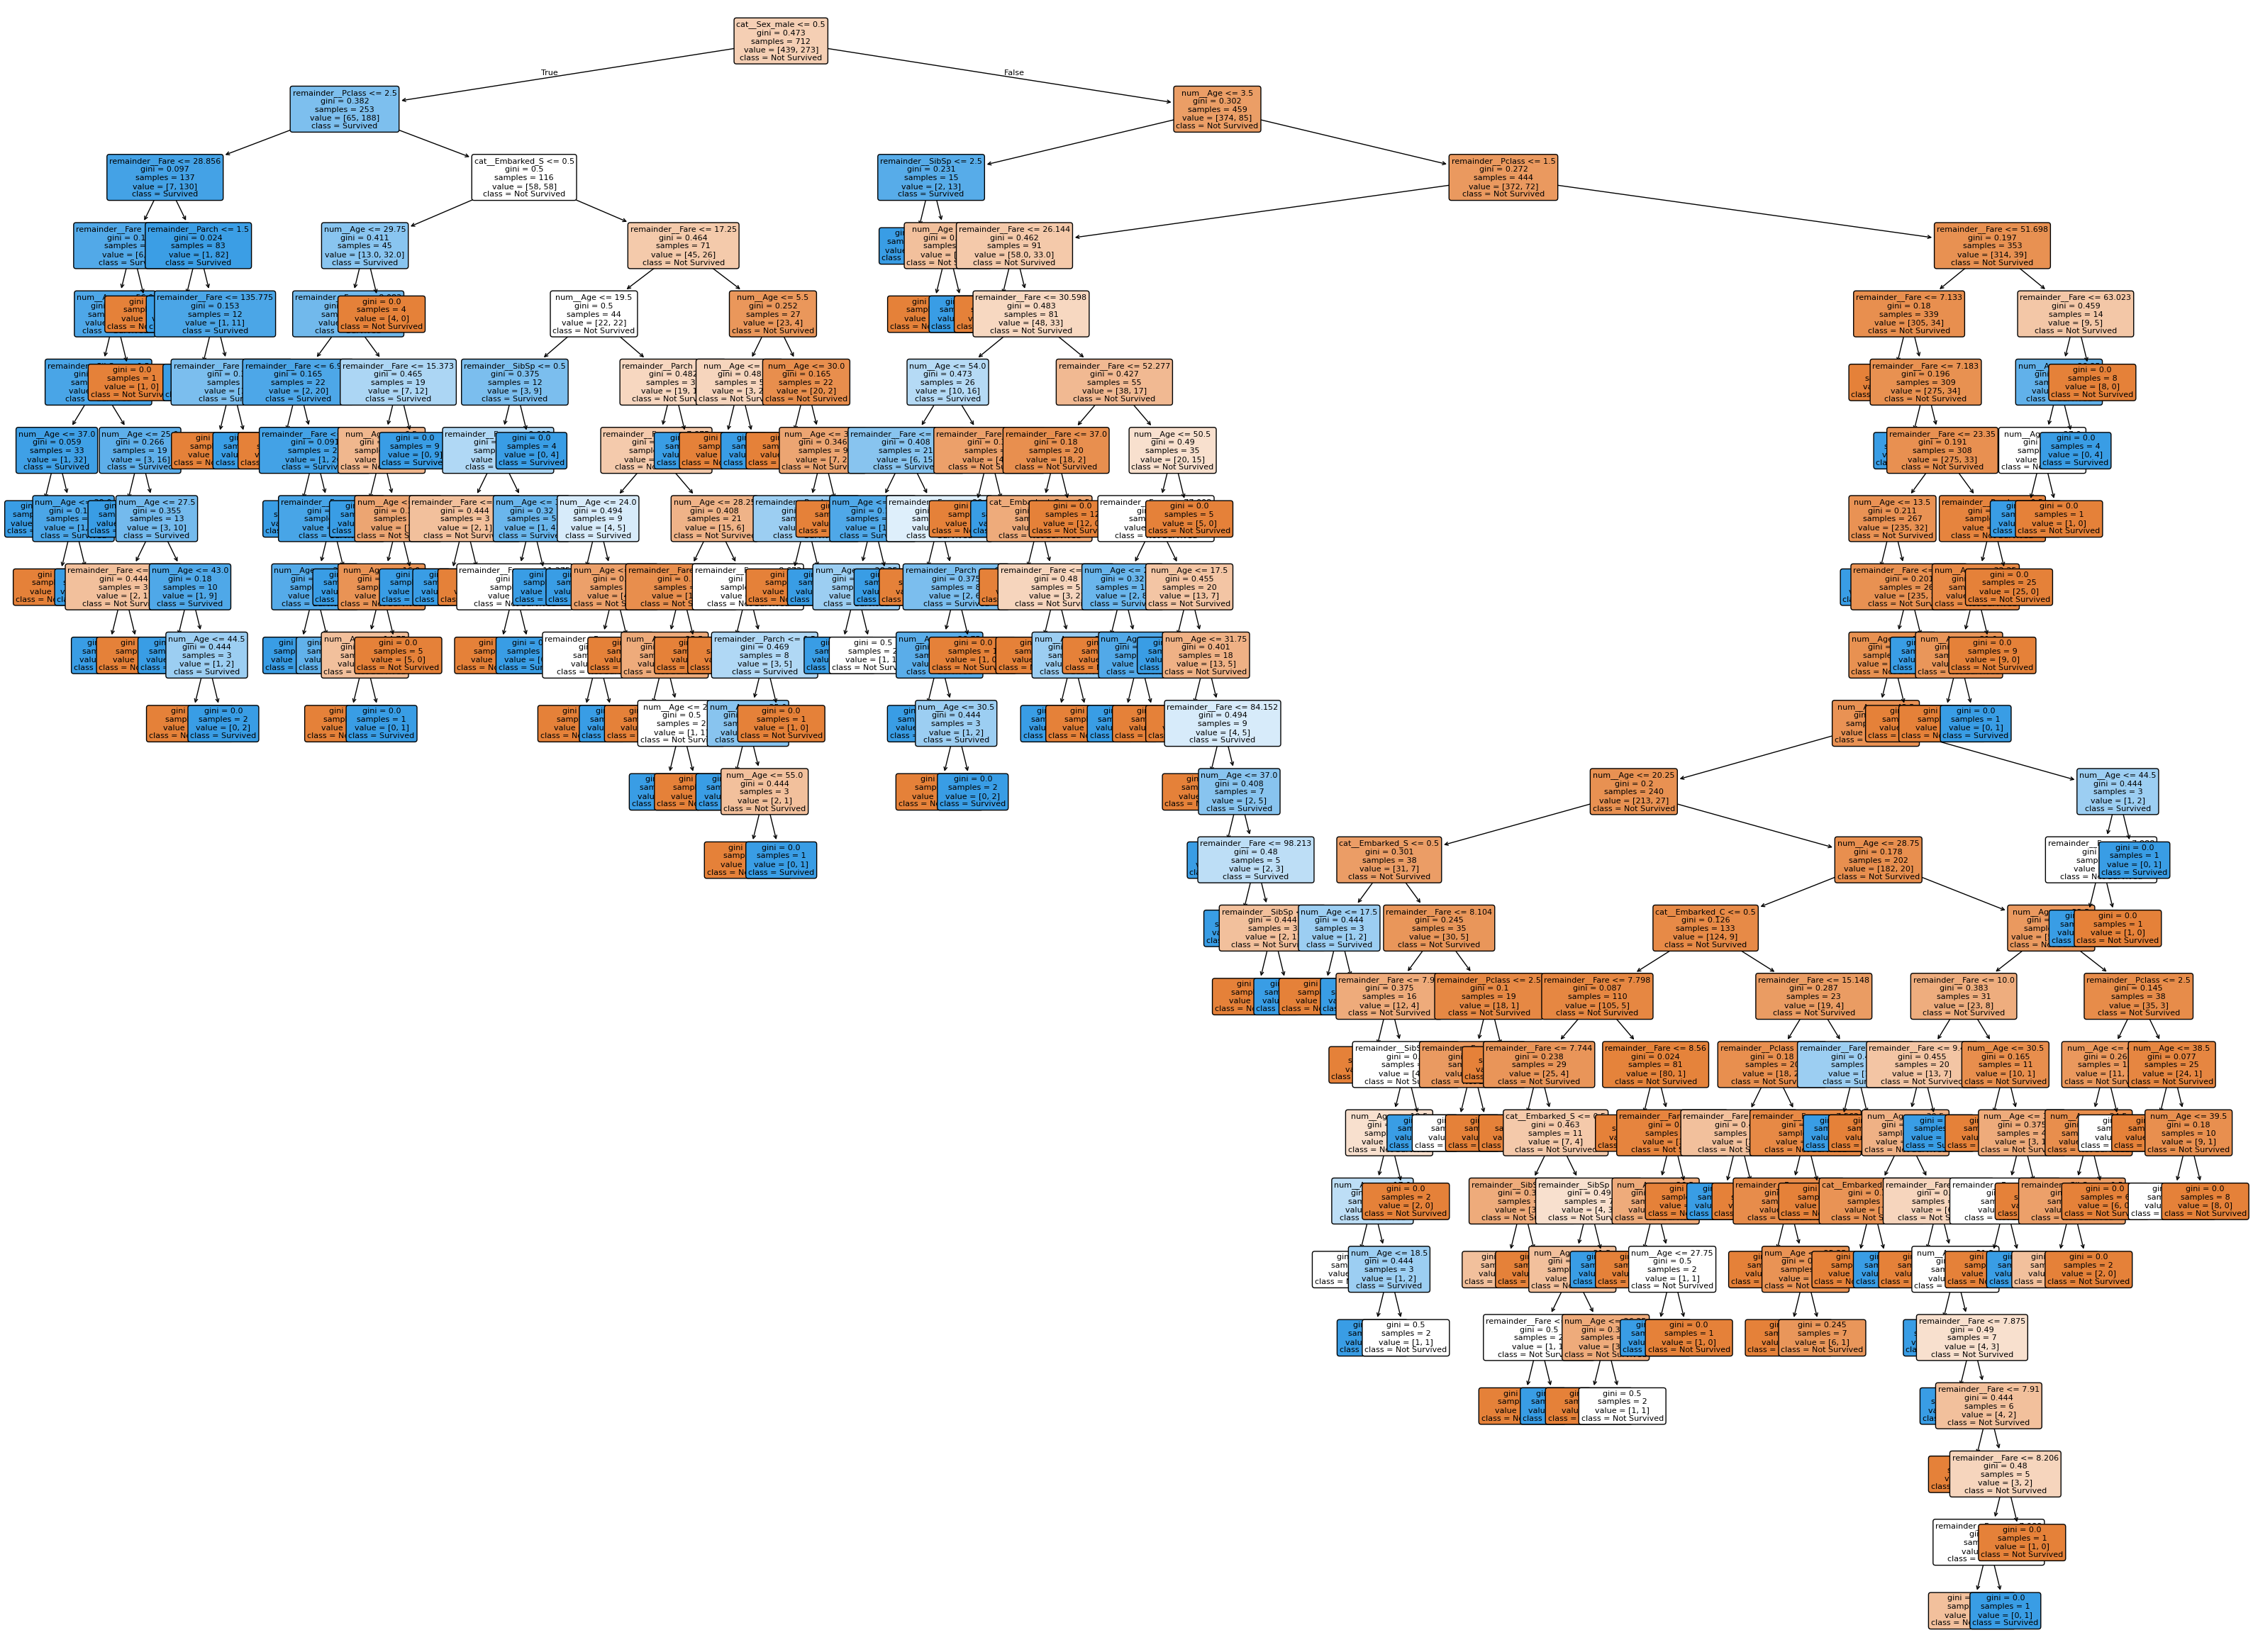

In [64]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(40,30))
plot_tree(model, feature_names=x_train.columns, class_names=['Not Survived', 'Survived'], filled=True, rounded=True, fontsize=8)
plt.show

In [69]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

depths = [2,3,5,10,None]

for depth in depths:
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(x_train,y_train)
    y_pred = model.predict(x_test)
    Accuracy = accuracy_score(y_test, y_pred)
    print(f"Depth: {depth} --> Accuracy: {Accuracy: .4f}")

Depth: 2 --> Accuracy:  0.7598
Depth: 3 --> Accuracy:  0.7933
Depth: 5 --> Accuracy:  0.7598
Depth: 10 --> Accuracy:  0.7933
Depth: None --> Accuracy:  0.8212


In [71]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

leaf_sizes = [1, 2, 5, 10, 20]

for leaf in leaf_sizes:

    model = DecisionTreeClassifier(
        min_samples_leaf=leaf,
        random_state=42
    )

    model.fit(x_train, y_train)

    y_pred = model.predict(x_test)

    accuracy = accuracy_score(y_test, y_pred)

    print(f"min_samples_leaf={leaf} --> Accuracy={accuracy:.4f}")

min_samples_leaf=1 --> Accuracy=0.8212
min_samples_leaf=2 --> Accuracy=0.8101
min_samples_leaf=5 --> Accuracy=0.7821
min_samples_leaf=10 --> Accuracy=0.7654
min_samples_leaf=20 --> Accuracy=0.7877


In [72]:
from sklearn.model_selection import GridSearchCV
help(GridSearchCV)

Help on class GridSearchCV in module sklearn.model_selection._search:

class GridSearchCV(BaseSearchCV)
 |  GridSearchCV(estimator, param_grid, *, scoring=None, n_jobs=None, refit=True, cv=None, verbose=0, pre_dispatch='2*n_jobs', error_score=nan, return_train_score=False)
 |  
 |  Exhaustive search over specified parameter values for an estimator.
 |  
 |  Important members are fit, predict.
 |  
 |  GridSearchCV implements a "fit" and a "score" method.
 |  It also implements "score_samples", "predict", "predict_proba",
 |  "decision_function", "transform" and "inverse_transform" if they are
 |  implemented in the estimator used.
 |  
 |  The parameters of the estimator used to apply these methods are optimized
 |  by cross-validated grid-search over a parameter grid.
 |  
 |  Read more in the :ref:`User Guide <grid_search>`.
 |  
 |  Parameters
 |  ----------
 |  estimator : estimator object
 |      This is assumed to implement the scikit-learn estimator interface.
 |      Either est

In [73]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [2, 3, 5, 10, None],
    "min_samples_leaf": [1, 2, 5, 10]
}

grid = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    scoring="accuracy",
    cv=5,
    n_jobs=-1,
    verbose=2,
    refit=True
)


In [74]:
grid.fit(x_train, y_train)

Fitting 5 folds for each of 40 candidates, totalling 200 fits


,estimator,DecisionTreeC...ndom_state=42)
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': [2, 3, ...], 'min_samples_leaf': [1, 2, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'entropy'


In [75]:
grid.best_params_

{'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 5}

In [76]:
grid.best_score_

np.float64(0.8259529203191175)

In [77]:
grid.best_estimator_

,criterion,'entropy'
,splitter,'best'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [78]:
y_pred = grid.predict(x_test)

In [79]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

0.770949720670391

In [80]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_test, y_pred)
print(cm)

print(classification_report(y_test, y_pred))

[[94 16]
 [25 44]]
              precision    recall  f1-score   support

           0       0.79      0.85      0.82       110
           1       0.73      0.64      0.68        69

    accuracy                           0.77       179
   macro avg       0.76      0.75      0.75       179
weighted avg       0.77      0.77      0.77       179



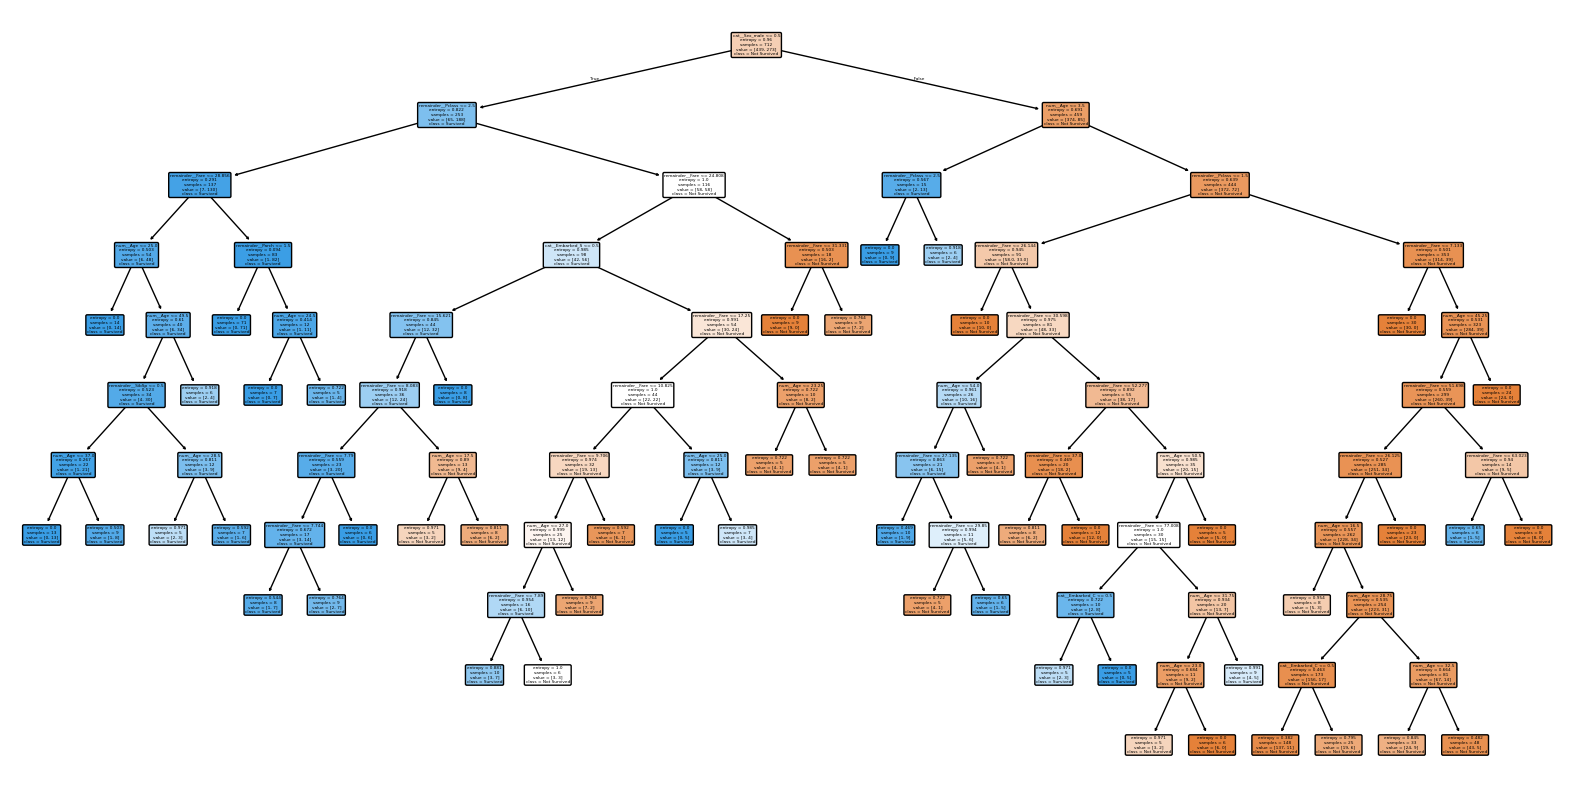

In [81]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))

plot_tree(
    grid.best_estimator_,
    feature_names=x_train.columns,
    class_names=["Not Survived", "Survived"],
    filled=True,
    rounded=True
)

plt.show()

In [82]:
grid.best_estimator_.feature_importances_

array([0.15363067, 0.        , 0.39012947, 0.01514502, 0.        ,
       0.01436785, 0.18714647, 0.00532224, 0.00699642, 0.22726185])

In [83]:
grid.best_estimator_.feature_names_in_

array(['num__Age', 'cat__Sex_female', 'cat__Sex_male', 'cat__Embarked_C',
       'cat__Embarked_Q', 'cat__Embarked_S', 'remainder__Pclass',
       'remainder__SibSp', 'remainder__Parch', 'remainder__Fare'],
      dtype=object)